In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import linalg as la
from tqdm import tqdm
import pickle
import seaborn as sns

import cmasher as cmr
import kwant

from koala import plotting as pl

from alter_morph.mean_field import hartree_fock

from alter_morph.kwant_utilities import (
    crack_hamiltonian_for_contacts_kwant,
    attach_leads_to_cracked,
)
from alter_morph.hamiltonians import (
    alt_hamiltonian,
    spectral_function,
    _hopping_matrix,
    find_m_per_state,
    find_spin_per_state,
    spectral_path,
)

aps_figwidth = 3.375 * 2
aps_halfwidth = 3.375

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times"],
    }
)

/opt/homebrew/Caskroom/miniforge/base/envs/kwant-test/lib/python3.12/site-packages/kwant/solvers/default.py:16: RuntimeWarning: MUMPS is not available, SciPy built-in solver will be used as a fallback. Performance can be very poor in this case.
  warnings.warn("MUMPS is not available, "


In [11]:
def fermi_level(energies, filling):
    return np.mean(
        energies[int(filling * len(energies)) - 1 : int(filling * len(energies)) + 1]
    )


def dos_at_fermi(energies, fermi_energy, broadening):
    norm_lorenzian = (1 / np.pi) * (
        broadening / ((energies - fermi_energy) ** 2 + broadening**2)
    )
    return np.mean(norm_lorenzian)

In [12]:
data_name = "data/detailed_phase_diagram_20_V0"
lattice_name = "analysis/voronoi_20"
# load data
with open(data_name + ".pickle", "rb") as f:
    data = pickle.load(f)

# load lattice
with open(lattice_name + ".pickle", "rb") as f:
    lattice = pickle.load(f)

In [13]:
# process the data

fillings = data["filling"]
J_vals = data["J"]

all_avg_mags = np.zeros([len(fillings), len(J_vals)])
all_variance_mags = np.zeros([len(fillings), len(J_vals)])

all_bond_diff_m = np.zeros([len(fillings), len(J_vals)])
all_bond_diff_n = np.zeros([len(fillings), len(J_vals)])
all_prop_relative_m = np.zeros([len(fillings), len(J_vals)])

all_energies = np.zeros([len(fillings), len(J_vals), lattice.n_vertices * 4])
broadening = 0.1

conds = np.zeros([len(fillings), len(J_vals), 2])

for i, filling in enumerate(tqdm(fillings)):
    for j, J in enumerate(J_vals):
        current_data = data["params"][i, j]

        # calculate the average magnetization
        all_avg_mags[i, j] = np.mean(current_data["m"])
        all_variance_mags[i, j] = np.var(current_data["n"])

        all_prop_relative_m[i, j] = np.mean(current_data["m"]) / np.max(
            current_data["m"]
        )

        all_energies[i, j] = data["data"][i, j]["energies"]
        conds[i, j] = data["data"][i, j]["spin_cond"].diagonal()

        # # calculate the density of states
        # all_dos_vals[i, j] = dos_at_fermi(
        #     all_energies[i, j], fermi_level(all_energies[i, j], filling), broadening
        # )

        # difference in m on bonds
        m = data["params"][i, j]["m"]
        m_on_bonds = m[lattice.edges.indices]
        all_bond_diff_m[i, j] = np.abs(m_on_bonds[:, 0] - m_on_bonds[:, 1]).mean()

        # difference in n on bonds
        n = data["params"][i, j]["n"]
        n_on_bonds = n[lattice.edges.indices]
        all_bond_diff_n[i, j] = np.abs(n_on_bonds[:, 0] - n_on_bonds[:, 1]).mean()

100%|██████████| 41/41 [00:00<00:00, 278.18it/s]


In [14]:
point_A = (0.1, 0.5)
point_B = (0.6, 0.15)
point_C = (0.6, 0.85)

points = [point_A, point_B, point_C]
argpoints = []
for i in range(3):
    point = points[i]
    arg_J = np.argmin(np.abs(J_vals - point[0]))
    arg_filling = np.argmin(np.abs(fillings - point[1]))
    argpoints.append((arg_J, arg_filling))
    point = (J_vals[arg_J], fillings[arg_filling])
    points[i] = point

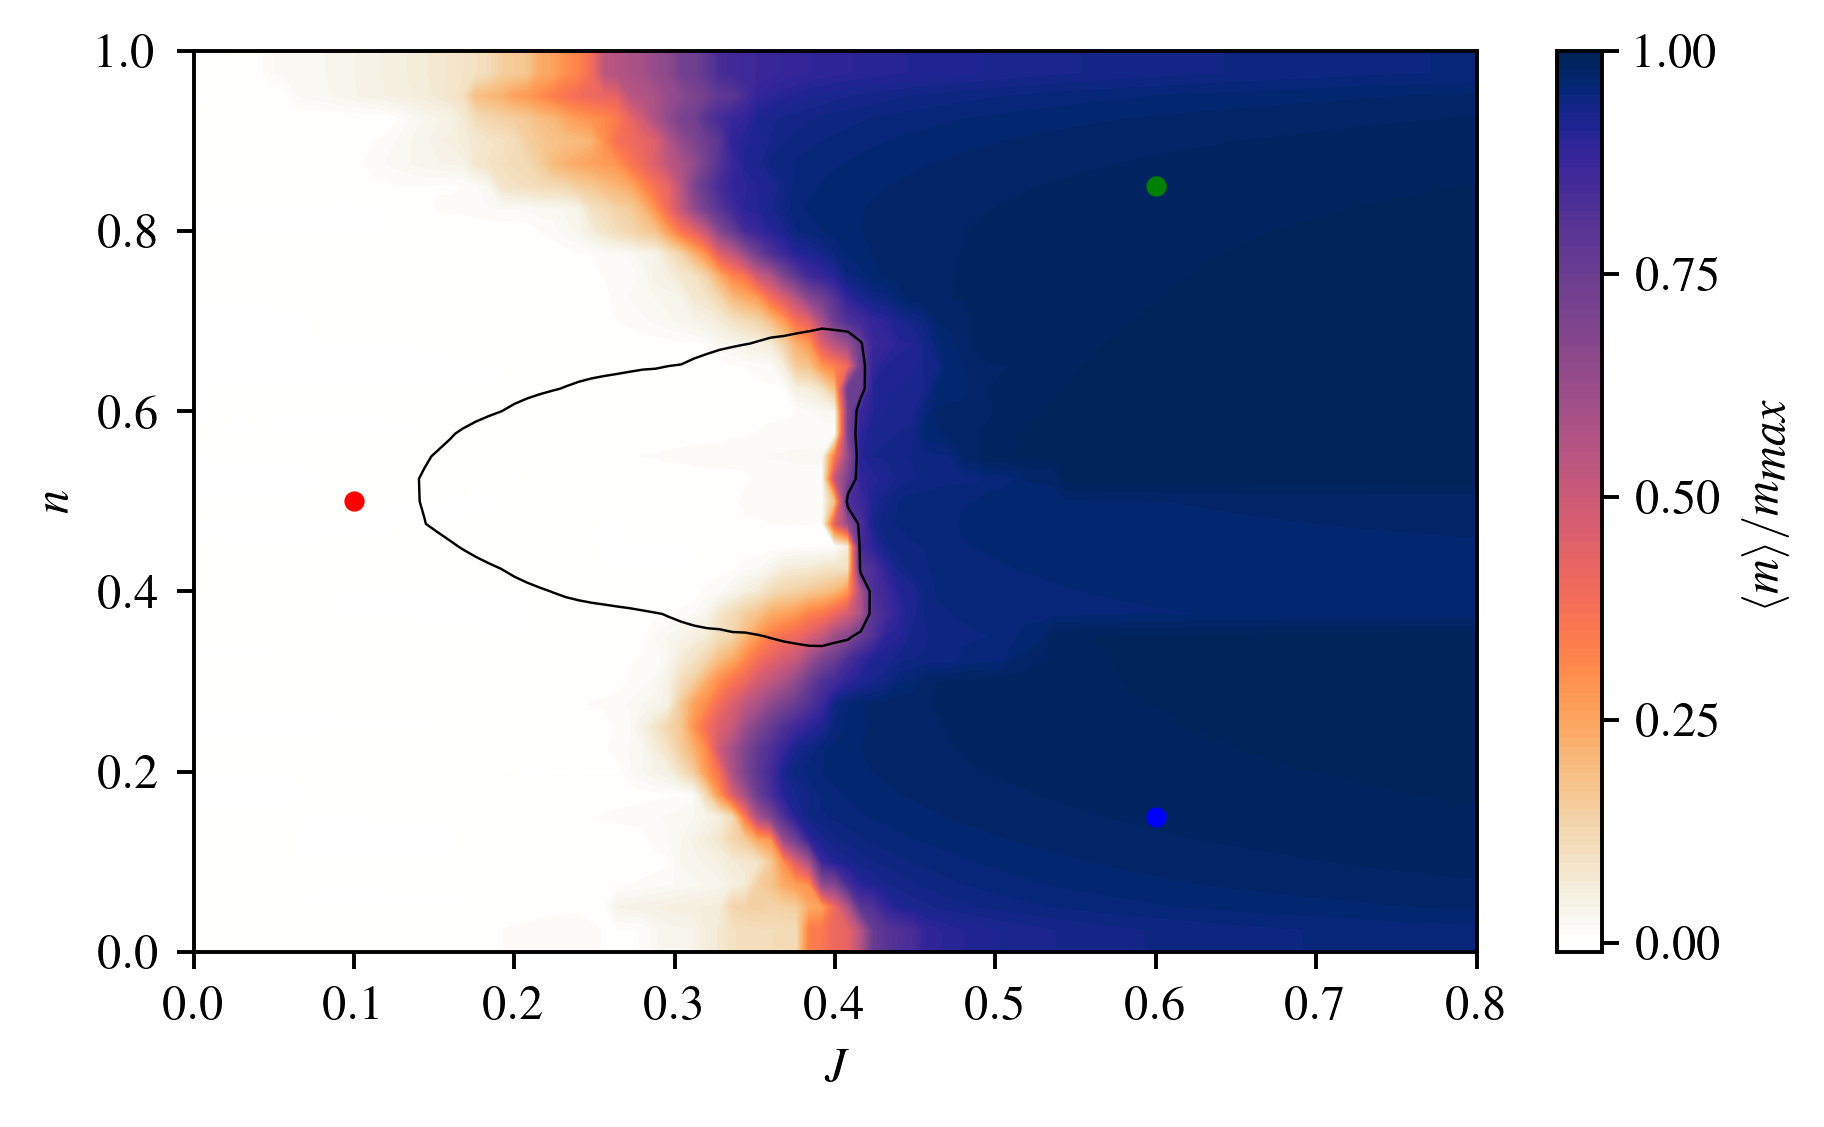

In [15]:
fig, ax = plt.subplots(
    1, 1, figsize=(aps_halfwidth + 2, (aps_halfwidth + 2) / 1.618), dpi=350
)


points = [point_A, point_B, point_C]
argpoints = []
for i in range(3):
    point = points[i]
    arg_J = np.argmin(np.abs(J_vals - point[0]))
    arg_filling = np.argmin(np.abs(fillings - point[1]))
    argpoints.append((arg_J, arg_filling))
    point = (J_vals[arg_J], fillings[arg_filling])
    points[i] = point

# plot the n on bonds
max_poss_mag = 2 - np.abs(4 * fillings - 2)
max_poss_mag[0] = 0.1
max_poss_mag[-1] = 0.1
all_avg_mags[0] = all_avg_mags[1]
all_avg_mags[-1] = all_avg_mags[-2]

scaled_mag = all_avg_mags / max_poss_mag[:, None]
# scaled_mag[np.where(scaled_mag>1)] =1


# plot the average magnetization
vlims = [0, 1.2]
im = ax.contourf(
    J_vals,
    fillings,
    scaled_mag,
    levels=100,
    cmap=cmr.torch_r,
    vmin=vlims[0],
    vmax=vlims[1],
)

# im2 = ax.contour(J_vals, fillings, all_avg_mags, levels=[0.2], colors="black", linewidths=0.5)
im2 = ax.contour(
    J_vals, fillings, all_bond_diff_n, levels=[0.5], colors="black", linewidths=0.5
)

clims = (0, 1)
cbar = fig.colorbar(im, ax=ax, ticks=np.linspace(clims[0], clims[1], 5))

# ax.set_ylim(fillings[1],fillings[-2])
ax.set_xlabel(r"$J$")
ax.set_ylabel(r"$n$")
cbar.set_label(r"$\langle m \rangle / m_{\textit{max}}$")


ax.scatter([point_A[0]], [point_A[1]], color="red", s=10)
ax.scatter([point_B[0]], [point_B[1]], color="blue", s=10)
ax.scatter([point_C[0]], [point_C[1]], color="green", s=10)

plt.tight_layout()
plt.savefig("talk_figs/phase_diag.png")
plt.show()

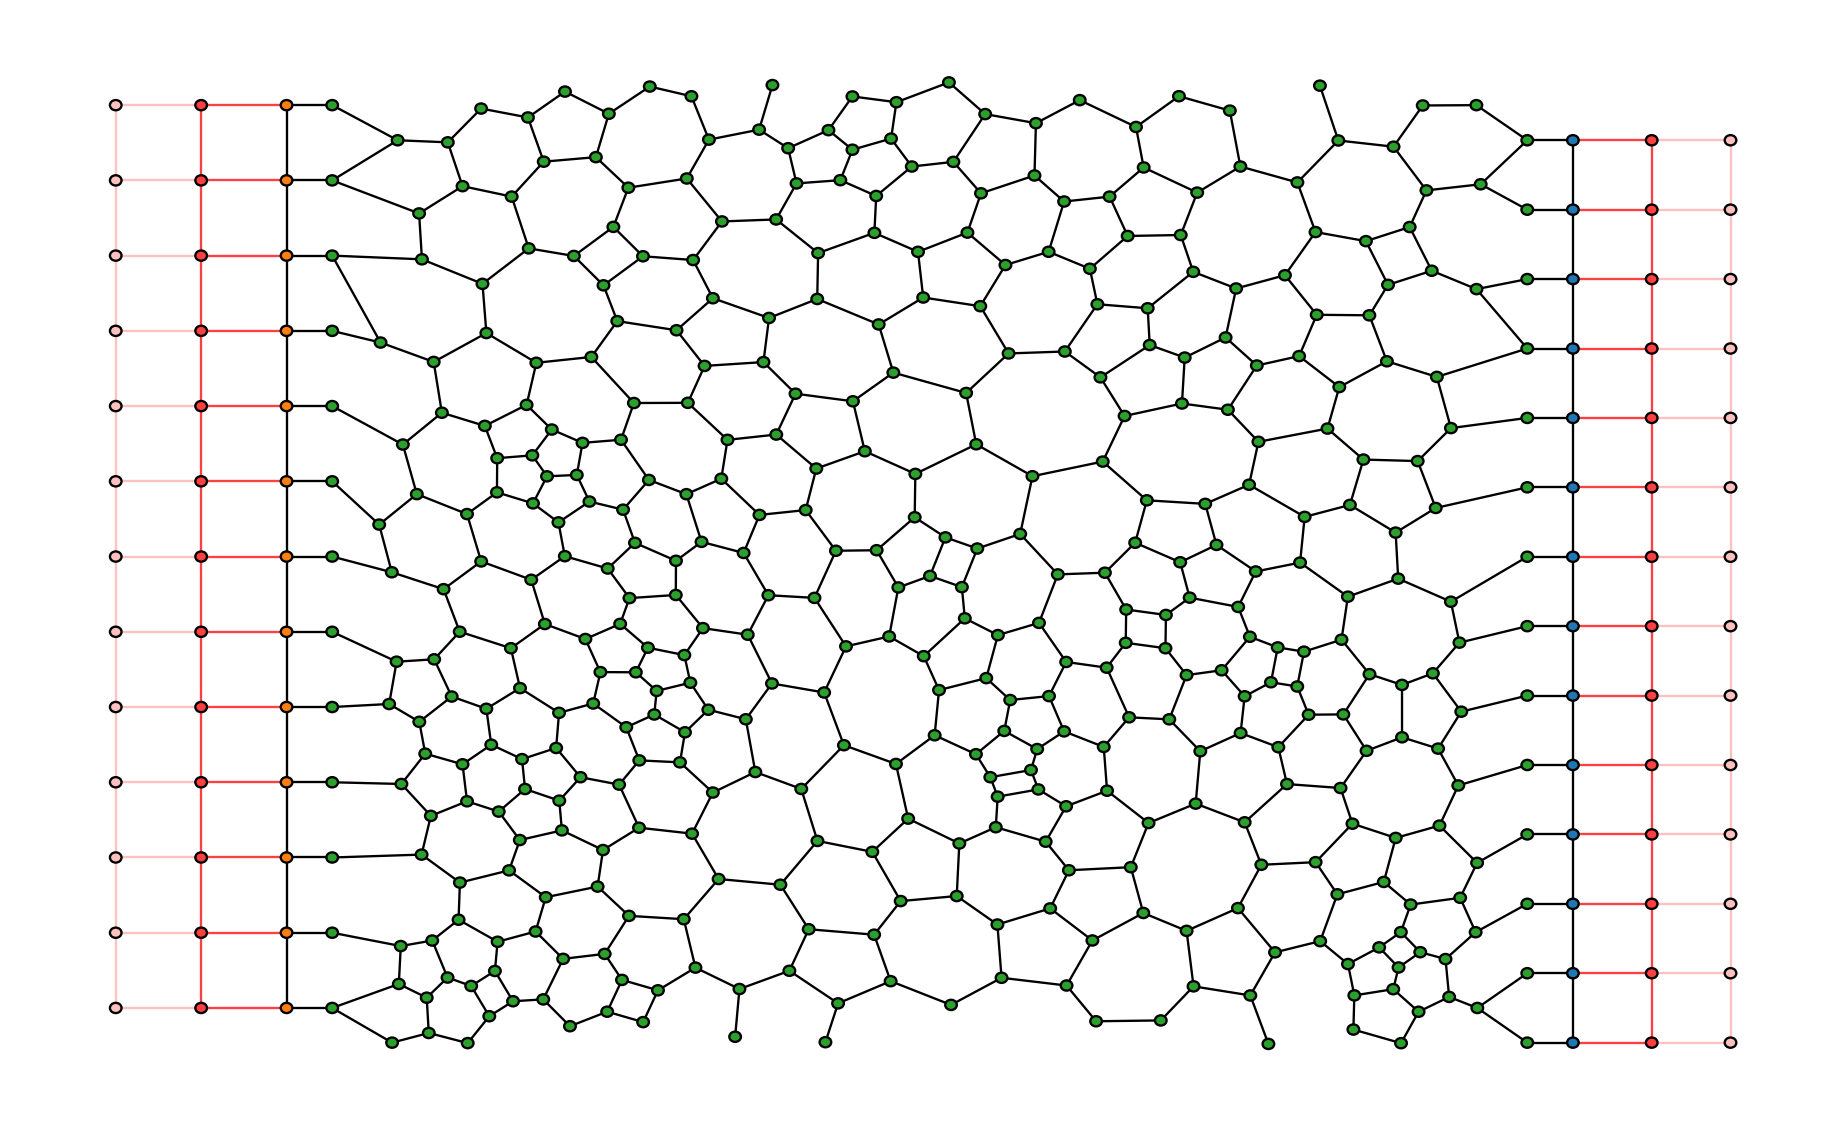

In [16]:
# plot the lattice

hamiltonian = alt_hamiltonian(lattice, 1, 0.5, 0.5, 0.5, m, n)
contact_lattice, k_lattice, k_system, contact_vertices = (
    crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
)
kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
    contact_lattice,
    k_lattice,
    k_system,
    contact_vertices,
    np.diag([-1, -1, 1, 1]),
    np.diag([-1, -1, 1, 1]),
    np.diag([-1, -1, 1, 1]),
)


fig, ax = plt.subplots(
    1, 1, figsize=(aps_halfwidth + 2, (aps_halfwidth + 2) / 1.618), dpi=350
)
kwant.plot(kwant_system_with_leads, site_lw=0.1, colorbar=False, show=False, ax=ax)
ax.axis("off")

plt.tight_layout()
plt.savefig("talk_figs/lattice.png")

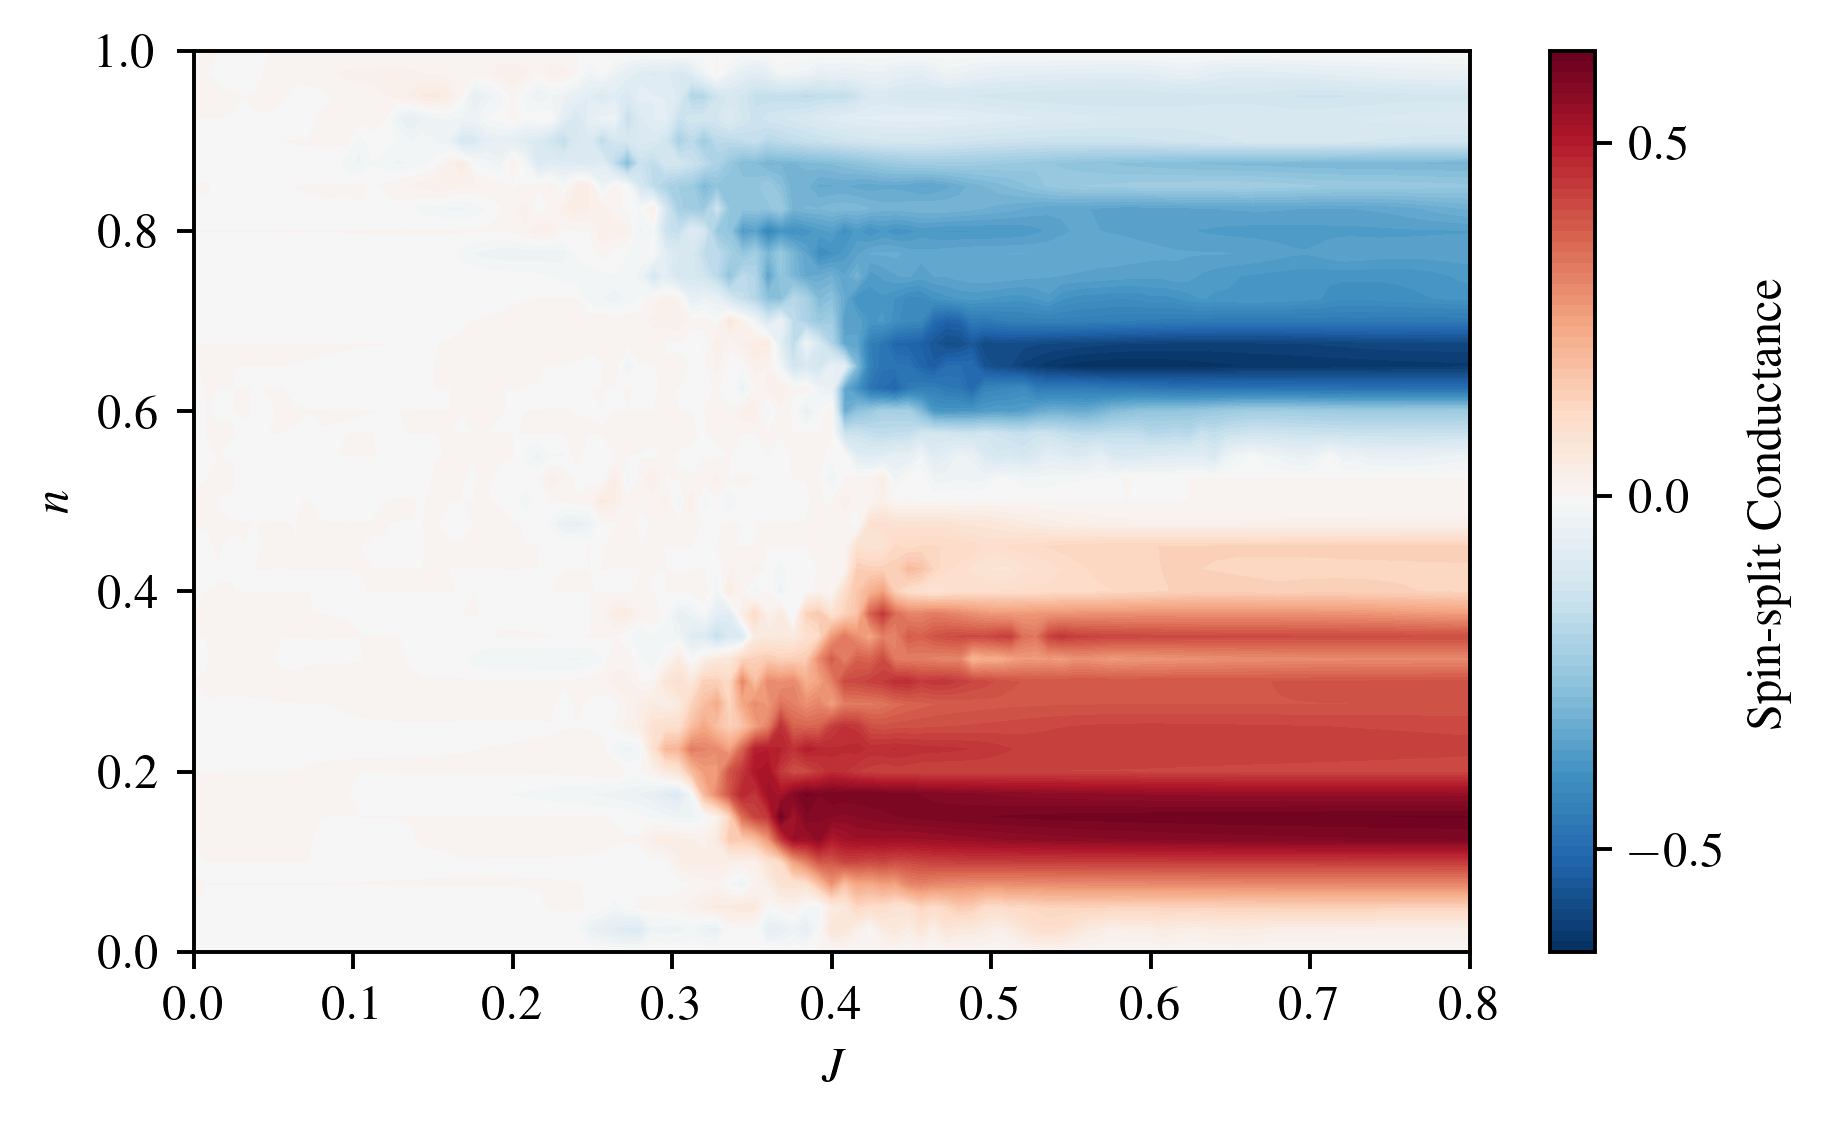

In [ ]:
fig, ax = plt.subplots(
    1, 1, figsize=(aps_halfwidth + 2, (aps_halfwidth + 2) / 1.618), dpi=350
)


points = [point_A, point_B, point_C]
argpoints = []
for i in range(3):
    point = points[i]
    arg_J = np.argmin(np.abs(J_vals - point[0]))
    arg_filling = np.argmin(np.abs(fillings - point[1]))
    argpoints.append((arg_J, arg_filling))
    point = (J_vals[arg_J], fillings[arg_filling])
    points[i] = point


# plot the average magnetization
# vlims = [0, 1.2]
im = ax.contourf(
    J_vals,
    fillings,
    -conds[:, :, 0] + conds[:, :, 1],
    levels=100,
    cmap="RdBu_r",
    # vmin=vlims[0],
    # vmax=vlims[1],
)


clims = (-1, 1)
cbar = fig.colorbar(im, ax=ax, ticks=np.linspace(clims[0], clims[1], 5))

# ax.set_ylim(fillings[1],fillings[-2])
ax.set_xlabel(r"$J$")
ax.set_ylabel(r"$n$")
cbar.set_label(r"Spin-split Conductance")


plt.tight_layout()
# plt.savefig("talk_figs/conds.png")
plt.show()

NameError: name 'lattice' is not defined

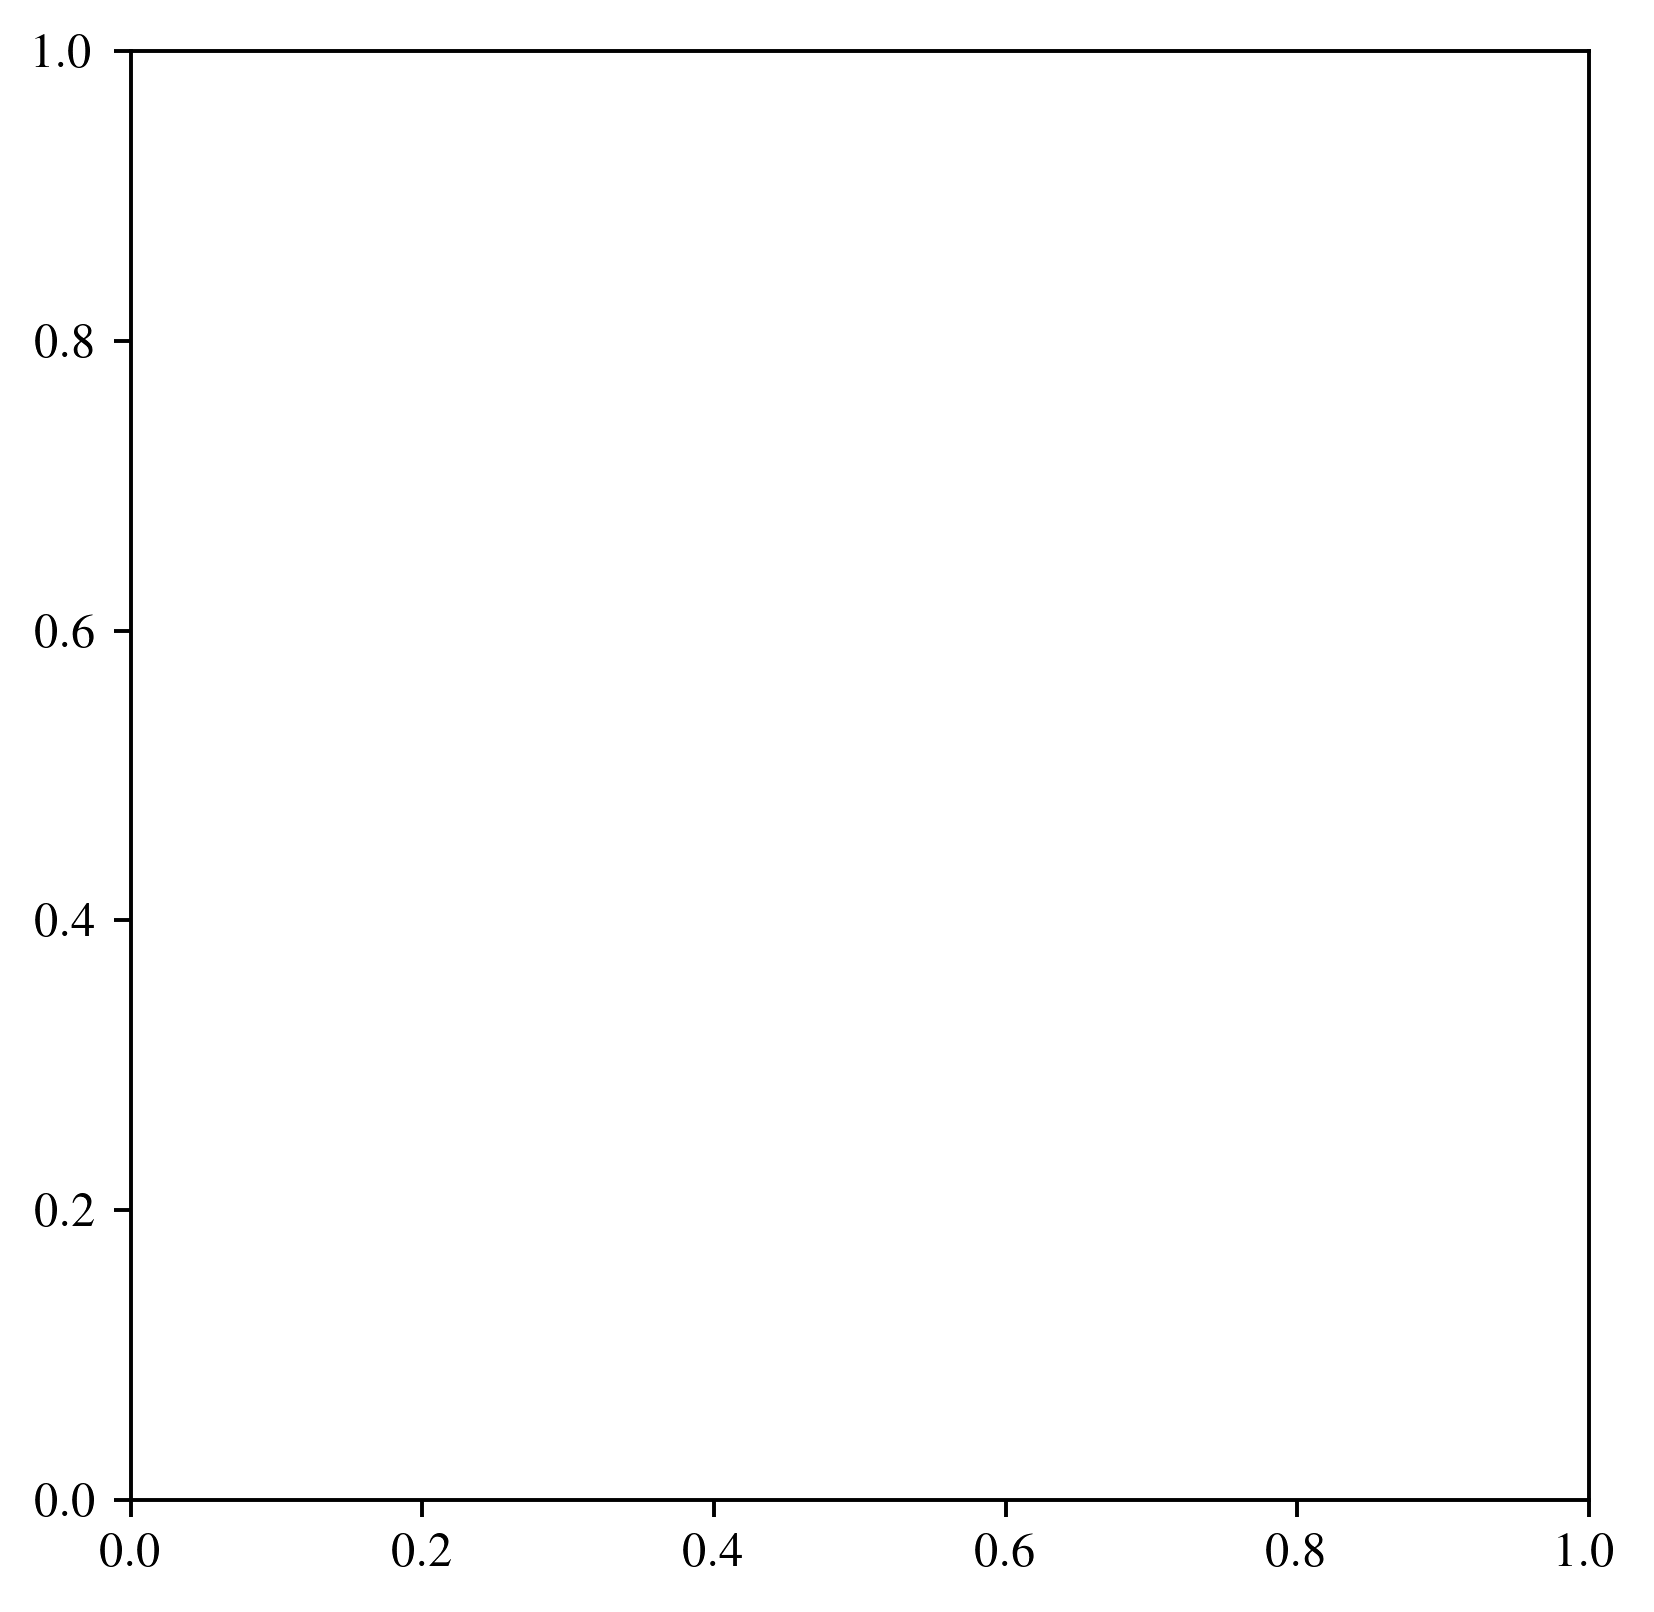

In [9]:
fig, ax = plt.subplots(figsize=(aps_halfwidth + 2, (aps_halfwidth + 2)), dpi=350)
pl.plot_edges(lattice)
plt.scatter(*lattice.vertices.positions.T, zorder=10)

ax.axis("off")

plt.savefig("talk_figs/lat_orig.png")

In [10]:
j_arg, fil_arg = argpoints[2]

parameters_at_point = data["params"][fil_arg, j_arg]

t1 = parameters_at_point["t1"]
t2 = parameters_at_point["t2"]
J = parameters_at_point["J"]
U = parameters_at_point["U"]
filling = parameters_at_point["filling"]
m = parameters_at_point["m"]
n = parameters_at_point["n"]
theta_offset = 0

hamiltonian_test = alt_hamiltonian(lattice, t1, t2, J, U, m, n, theta_offset)
energies, states = la.eigh(hamiltonian_test)

IndexError: list index out of range

In [ ]:
IPR = np.sum(states**4, axis=0)
IPR = IPR / np.max(IPR)
plt.plot(energies, 1 / IPR)
ax = plt.gca()
# ax.set_yscale('log')
ax.set_xlim(2.6, 3)

: 

: 

80
(400,)


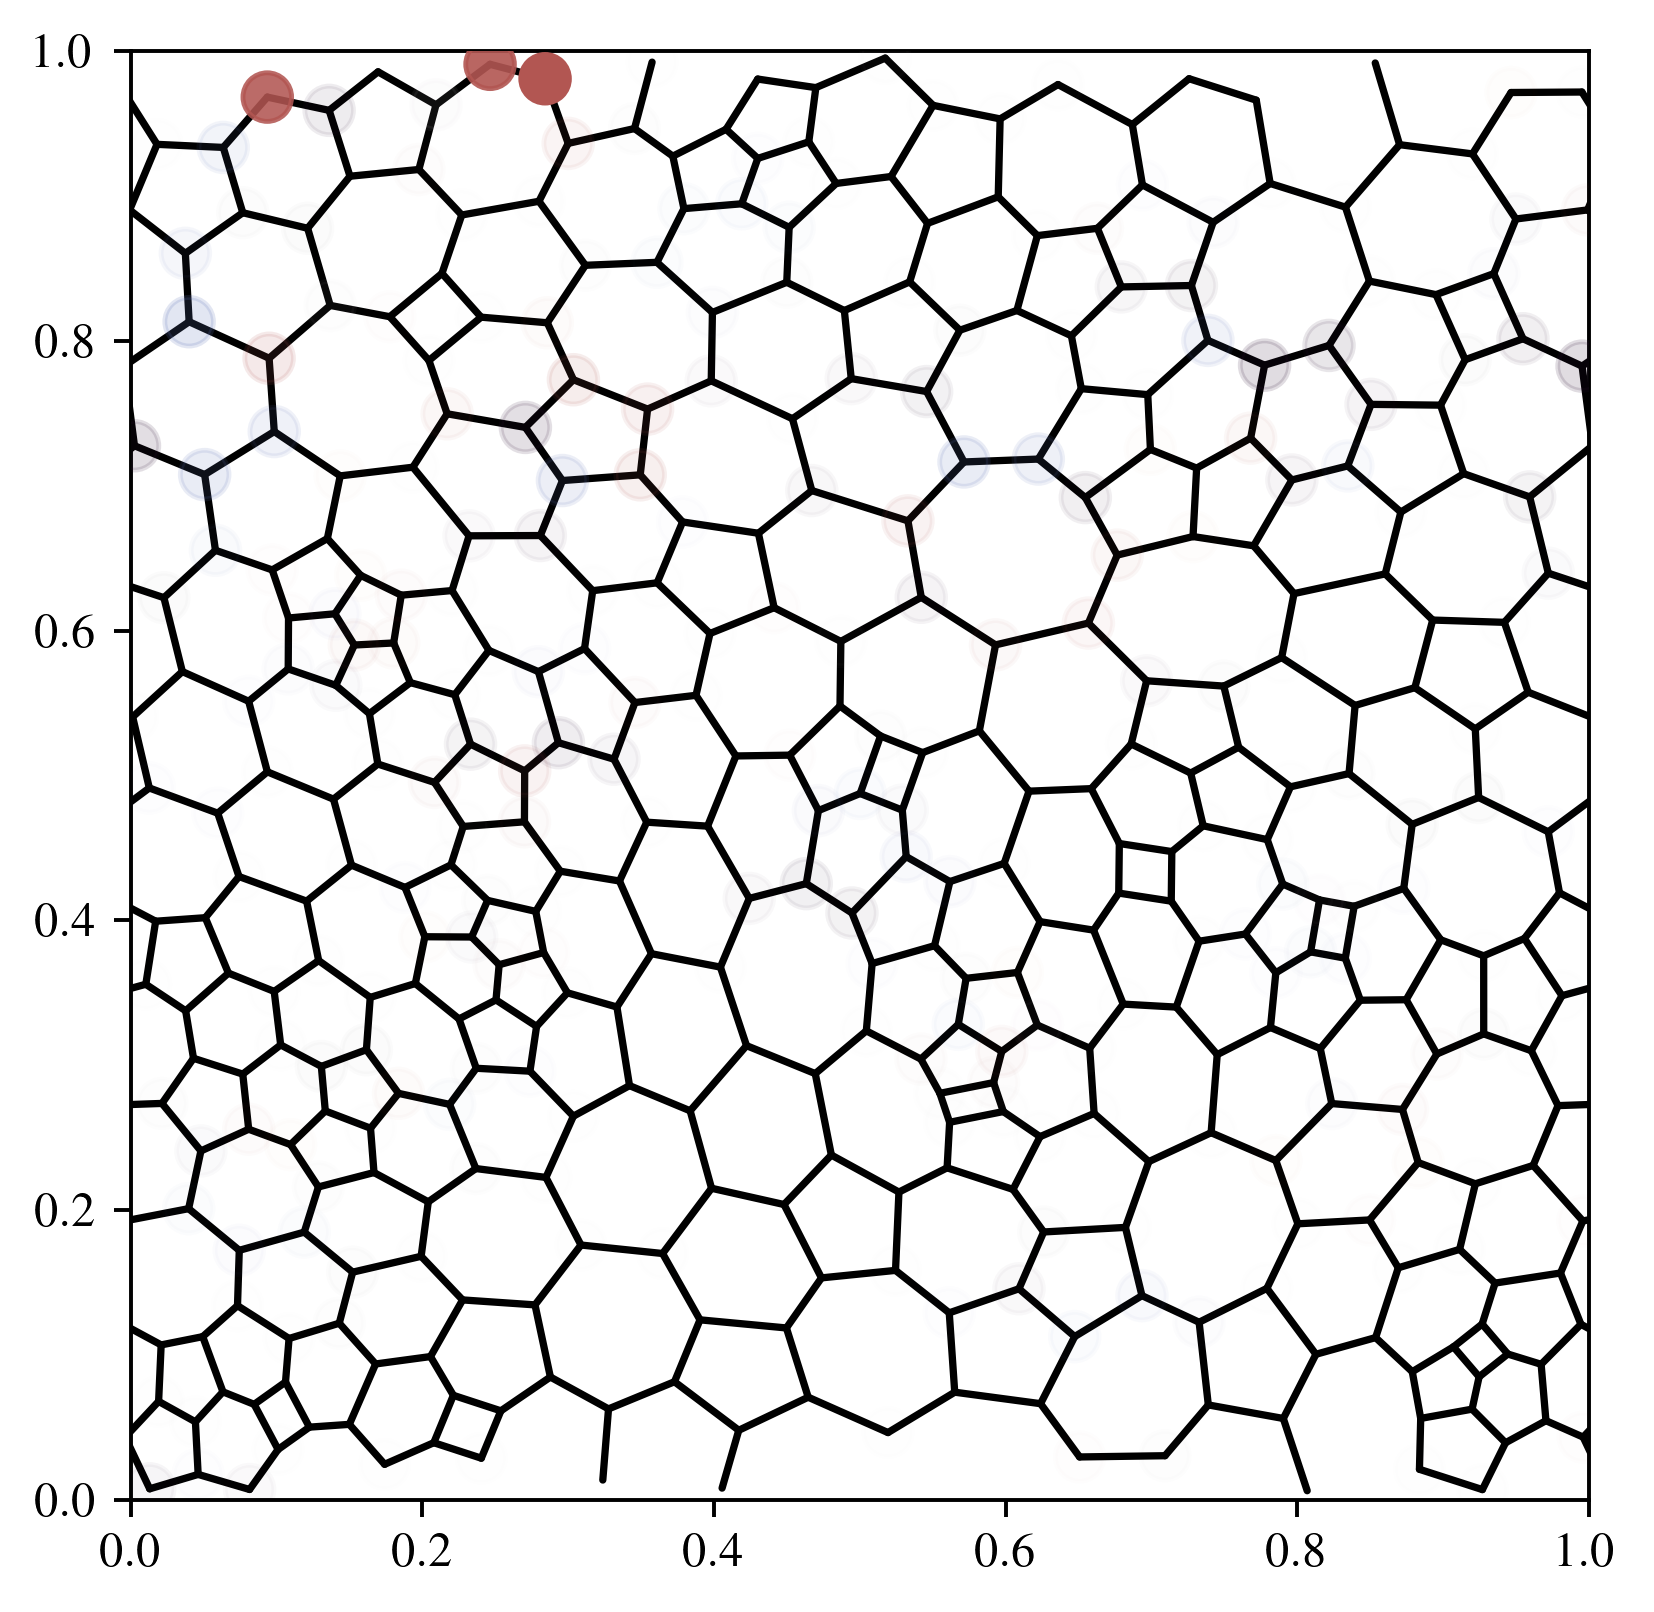

: 

: 

In [ ]:
state_id += 1
print(state_id)
state = states[:, state_id]

mags = np.abs(state) ** 2
mags = np.sum(mags.reshape(-1, 4), axis=1)
mags = mags / np.max(mags)
print(mags.shape)


phases = np.angle(state)
phases = phases.reshape(-1, 4)
phases = np.sum(phases, axis=1)

fig, ax = plt.subplots(figsize=(aps_halfwidth + 2, (aps_halfwidth + 2)), dpi=350)
pl.plot_edges(lattice)
plt.scatter(
    *lattice.vertices.positions.T,
    zorder=10,
    alpha=mags,
    s=100,
    c=phases,
    cmap="twilight"
)

: 

: 

In [ ]:
plt.plot(mags)
mags.shape

: 

: 